# Seren Tiny Instance: Gurobi Step-by-Step

This notebook starts with only one generated instance:

```text
data/instances/seren_pretrain/tiny_6_jobs
```

The goal is not to run a large benchmark yet. The goal is to validate, slowly, that the generated Seren instance can be digested by the MILP formulation and that the result is interpretable.

Important modeling choice in this notebook:

- the exported instance keeps both `node_units_required` and `block_units_required`;
- for Gurobi/MILP realism, we solve with **node units**;
- therefore, before building the model, we set `gpu_count_required = node_units_required` and `cluster.gpu_capacity = node_capacity`.

The QUBO path can still use `block_units_required` later if we need a smaller binary encoding.


In [1]:
from __future__ import annotations

import json
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from gurobipy import GRB
from dwave.samplers import SimulatedAnnealingSampler

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import ModelConfig
from src.data.gpu_unit_adapter import adapt_gpu_unit
from src.milp.gurobi_model import build_milp_model
from src.milp.solve import solve_model
from src.quantum.qubo_builder import (
    QuboPenaltyWeights,
    build_scheduling_qubo,
    decode_qubo_sample,
    to_dimod_bqm,
    validate_decoded_schedule,
)

INSTANCE_DIR = PROJECT_ROOT / "data" / "instances" / "seren_pretrain" / "tiny_6_jobs"
TIME_LIMIT_SECONDS = 60
MIP_GAP = 0.001


## 1. Load the Tiny Instance

The generated files are loaded as plain CSV. We inspect them before modifying anything.


In [2]:
jobs_raw = pd.read_csv(INSTANCE_DIR / "jobs.csv")
clusters_raw = pd.read_csv(INSTANCE_DIR / "clusters.csv")
hourly_df = pd.read_csv(INSTANCE_DIR / "hourly_inputs.csv")
metadata = json.loads((INSTANCE_DIR / "metadata.json").read_text())

metadata, jobs_raw.head(), clusters_raw


({'source': 'Seren Pretrain trace',
  'source_rows': 903,
  'eligible_rows_after_duration_filter': 903,
  'max_duration_hours': 10.0,
  'sampled_jobs': 6,
  'seed': 31,
  'horizon_hours': 24,
  'slot_minutes': 60,
  'horizon_slots': 24,
  'capacity_note': 'Total GPU capacity uses the confirmed Seren cluster configuration.',
  'gpu_type': 'NVIDIA A100-SXM 80GB',
  'gpu_tdp_kw': 0.4,
  'gpu_power_source': 'NVIDIA A100 datasheet max TDP for A100 80GB SXM',
  'gpu_power_source_url': 'https://www.nvidia.com/content/dam/en-zz/Solutions/Data-Center/a100/pdf/nvidia-a100-datasheet-nvidia-us-2188504-web.pdf',
  'flexibility_hours_options': [2, 3, 4],
  'physical_nodes': 286,
  'cpu_threads_per_node': 128,
  'raw_gpu_capacity': 2288,
  'node_gpu': 8,
  'node_capacity': 286,
  'unit_gpu': 96,
  'block_gpu': 96,
  'block_capacity': 23,
  'gpu_capacity_blocks': 23,
  'aggregate_node_utilization_upper_bound': 0.006993006993006993,
  'aggregate_gpu_block_utilization_upper_bound': 0.010869565217391304,

## 1.1 Energy Inputs Used in This Instance

The job trace does not contain electricity prices or renewable generation. The generated `hourly_inputs.csv` therefore uses a simple synthetic scenario:

```text
renewable_available[t] = solar-shaped profile, peaking around midday

grid_price[t] = 55  for hours 10-16
              = 90  for hours 18-22
              = 70  otherwise

renewable_price = 35
PUE = 1.25
```

This is not a market-calibrated tariff yet. It is a controlled test profile designed to create cheap and expensive scheduling periods. Gurobi and QUBO both use the same `hourly_inputs.csv`, but QUBO uses an approximate effective price instead of explicitly dispatching renewable/grid energy.


In [3]:
hourly_df.head(24)


,hour,renewable_available,grid_price,pue,baseline_load
0,0,0.000000e+00,70.0,1.25,0.0
1,1,0.000000e+00,70.0,1.25,0.0
2,2,0.000000e+00,70.0,1.25,0.0
3,3,0.000000e+00,70.0,1.25,0.0
4,4,0.000000e+00,70.0,1.25,0.0
5,5,0.000000e+00,70.0,1.25,0.0
6,6,0.000000e+00,70.0,1.25,0.0
7,7,1.332400e-01,70.0,1.25,0.0
8,8,2.574000e-01,70.0,1.25,0.0
9,9,3.640186e-01,70.0,1.25,0.0


## 2. Convert GPU Capacity to Node Units for Gurobi

The MILP resource constraint reads `gpu_count_required <= gpu_capacity`. For this notebook we want that quantity to mean **nodes**, not 96-GPU blocks.

So we convert:

```text
job gpu_count_required = node_units_required
cluster gpu_capacity = node_capacity
```

The power column remains in MW and is still computed from raw GPU count and A100 TDP.


In [4]:
GPU_UNIT_MODE_GUROBI = "node"

jobs_df, clusters_df = adapt_gpu_unit(jobs_raw, clusters_raw, GPU_UNIT_MODE_GUROBI)

# CPU and memory are intentionally disabled for this first tiny check because
# the generated Pretrain instances do not yet provide per-job CPU/memory demand.
jobs_df["cpu_required"] = 0.0
jobs_df["memory_required_gb"] = 0.0

jobs_df[[
    "job_id", "earliest_start", "latest_start", "duration", "raw_gpu_num",
    "node_units_required", "block_units_required", "gpu_count_required", "power"
]], clusters_df[["cluster_id", "gpu_capacity", "node_capacity", "block_capacity", "capacity"]]


(               job_id  earliest_start  latest_start  duration  raw_gpu_num  \
 0  seren_pretrain_000              13            16         1           64   
 1  seren_pretrain_001              13            17         1           64   
 2  seren_pretrain_002              10            13         1           64   
 3  seren_pretrain_003              13            15         1           64   
 4  seren_pretrain_004              12            15         1           64   
 5  seren_pretrain_005              12            16         1           64   
 
    node_units_required  block_units_required  gpu_count_required   power  
 0                    8                     1                   8  0.0256  
 1                    8                     1                   8  0.0256  
 2                    8                     1                   8  0.0256  
 3                    8                     1                   8  0.0256  
 4                    8                     1                   8

## 3. Build and Solve the MILP

We use hourly PUE values from `hourly_inputs.csv`. Battery is disabled for this first check.

The contracted power is set to the full facility capacity after PUE. That avoids turning this first notebook into a peak-penalty stress test; here we first want to verify scheduling and resource feasibility.


In [5]:
facility_capacity_mw = float(clusters_df["capacity"].sum()) * float(hourly_df["pue"].iloc[0])

config = ModelConfig(
    contracted_power=facility_capacity_mw,
    renewable_price=35.0,
    peak_price=1000.0,
    delta_t=1.0,
    pue=float(hourly_df["pue"].iloc[0]),
    battery_power_capacity=0.0,
    battery_energy_capacity=0.0,
)

model, variables = build_milp_model(
    jobs_df,
    hourly_df,
    clusters_df,
    config,
    model_name="seren_tiny_pretrain_node_units",
    enforce_gpu_constraints=True,
    enforce_cpu_constraints=False,
    enforce_memory_constraints=False,
)

solve_model(model, time_limit=TIME_LIMIT_SECONDS, mip_gap=MIP_GAP)
status_name = {value: name for name, value in GRB.__dict__.items() if name.isupper()}.get(model.Status, str(model.Status))
{
    "status": status_name,
    "runtime_s": model.Runtime,
    "objective": model.ObjVal if model.SolCount else None,
    "solution_count": model.SolCount,
    "assignment_vars": len(variables["x"]),
}


Set parameter Username


Set parameter LicenseID to value 2828833


Academic license - for non-commercial use only - expires 2027-05-29


Set parameter TimeLimit to value 60


Set parameter MIPGap to value 0.001


...

Thread count was 1 (of 10 available processors)


Solution count 1: 6.72 


Optimal solution found (tolerance 1.00e-03)


Best objective 6.720000000000e+00, best bound 6.720000000000e+00, gap 0.0000%


{'status': 'FEASRELAX_CARDINALITY',
 'runtime_s': 0.009070158004760742,
 'objective': 6.720000000000001,
 'solution_count': 1,
 'assignment_vars': 25}

## 4. Extract the Schedule

Each selected assignment variable gives one row of the schedule: job, cluster, start slot, duration, and resource demand.


In [6]:
selected_rows = []
if model.SolCount:
    for (job_id, cluster, start), var in variables["x"].items():
        if var.X > 0.5:
            job = jobs_df.loc[jobs_df["job_id"] == job_id].iloc[0]
            selected_rows.append({
                "job_id": job_id,
                "cluster": cluster,
                "start": int(start),
                "end": int(start + job["duration"]),
                "duration": int(job["duration"]),
                "raw_gpu_num": int(job["raw_gpu_num"]),
                "node_units_required": int(job["node_units_required"]),
                "block_units_required": int(job["block_units_required"]),
                "power_mw": float(job["power"]),
            })

schedule_df = pd.DataFrame(selected_rows).sort_values(["start", "job_id"]).reset_index(drop=True)
schedule_df


,job_id,cluster,start,end,duration,raw_gpu_num,node_units_required,block_units_required,power_mw
0,seren_pretrain_002,seren_pretrain_pool,10,11,1,64,8,1,0.0256
1,seren_pretrain_004,seren_pretrain_pool,12,13,1,64,8,1,0.0256
2,seren_pretrain_005,seren_pretrain_pool,12,13,1,64,8,1,0.0256
3,seren_pretrain_000,seren_pretrain_pool,13,14,1,64,8,1,0.0256
4,seren_pretrain_001,seren_pretrain_pool,13,14,1,64,8,1,0.0256
5,seren_pretrain_003,seren_pretrain_pool,13,14,1,64,8,1,0.0256


## 5. Visual Check

This plot is deliberately simple: it shows whether the tiny instance creates a reasonable schedule inside the 24-hour horizon.


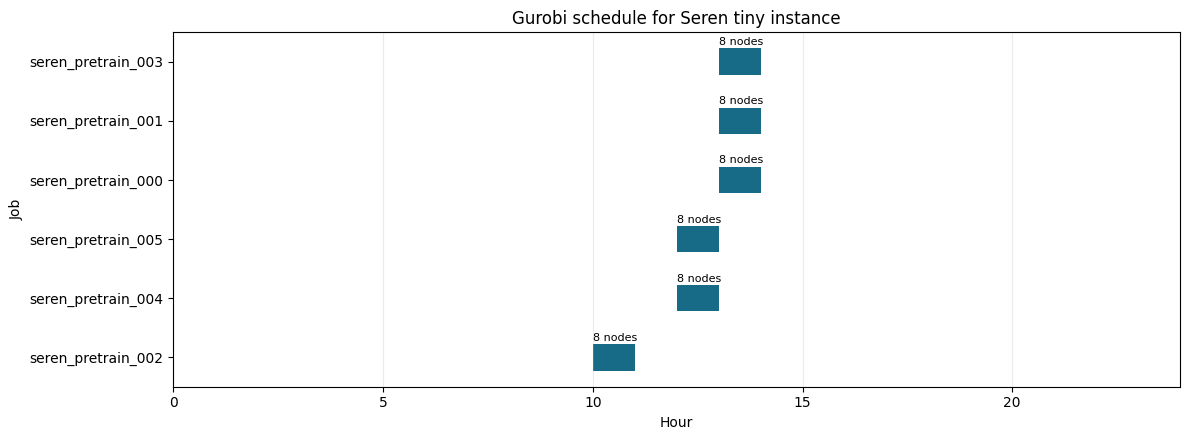

In [7]:
if not schedule_df.empty:
    fig, ax = plt.subplots(figsize=(12, 4.5))
    for y, row in schedule_df.iterrows():
        ax.barh(y, row["duration"], left=row["start"], height=0.45, color="#176b87")
        ax.text(row["start"], y + 0.28, f'{row["node_units_required"]} nodes', fontsize=8)
    ax.set_title("Gurobi schedule for Seren tiny instance")
    ax.set_xlabel("Hour")
    ax.set_ylabel("Job")
    ax.set_yticks(range(len(schedule_df)))
    ax.set_yticklabels(schedule_df["job_id"])
    ax.set_xlim(0, 24)
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()


## 6. Resource and Energy Profile

This table checks hourly node utilization, IT load, facility load after PUE, renewable use, and grid import. For tiny instances, utilization should be low; the point is correctness before stress.


In [8]:
profile_rows = []
if model.SolCount:
    for hour in variables["hours"]:
        node_used = 0.0
        for _, row in schedule_df.iterrows():
            if row["start"] <= hour < row["end"]:
                node_used += row["node_units_required"]
        profile_rows.append({
            "hour": hour,
            "node_used": node_used,
            "node_utilization": node_used / float(clusters_df["gpu_capacity"].sum()),
            "it_load_mw": variables["it_load"][hour].getValue(),
            "facility_load_mw": variables["total_load"][hour].getValue(),
            "renewable_used_mw": variables["R"][hour].X,
            "grid_used_mw": variables["Q"][hour].X,
            "renewable_available_mw": variables["renewable_available"][hour],
        })

profile_df = pd.DataFrame(profile_rows)
profile_df.head(24)


,hour,node_used,node_utilization,it_load_mw,facility_load_mw,renewable_used_mw,grid_used_mw,renewable_available_mw
0,0,0.0,0.000000,0.0000,0.000,0.000,0.0,0.000000e+00
1,1,0.0,0.000000,0.0000,0.000,0.000,0.0,0.000000e+00
2,2,0.0,0.000000,0.0000,0.000,0.000,0.0,0.000000e+00
3,3,0.0,0.000000,0.0000,0.000,0.000,0.0,0.000000e+00
4,4,0.0,0.000000,0.0000,0.000,0.000,0.0,0.000000e+00
5,5,0.0,0.000000,0.0000,0.000,0.000,0.0,0.000000e+00
6,6,0.0,0.000000,0.0000,0.000,0.000,0.0,0.000000e+00
7,7,0.0,0.000000,0.0000,0.000,0.000,0.0,1.332400e-01
8,8,0.0,0.000000,0.0000,0.000,0.000,0.0,2.574000e-01
9,9,0.0,0.000000,0.0000,0.000,0.000,0.0,3.640186e-01


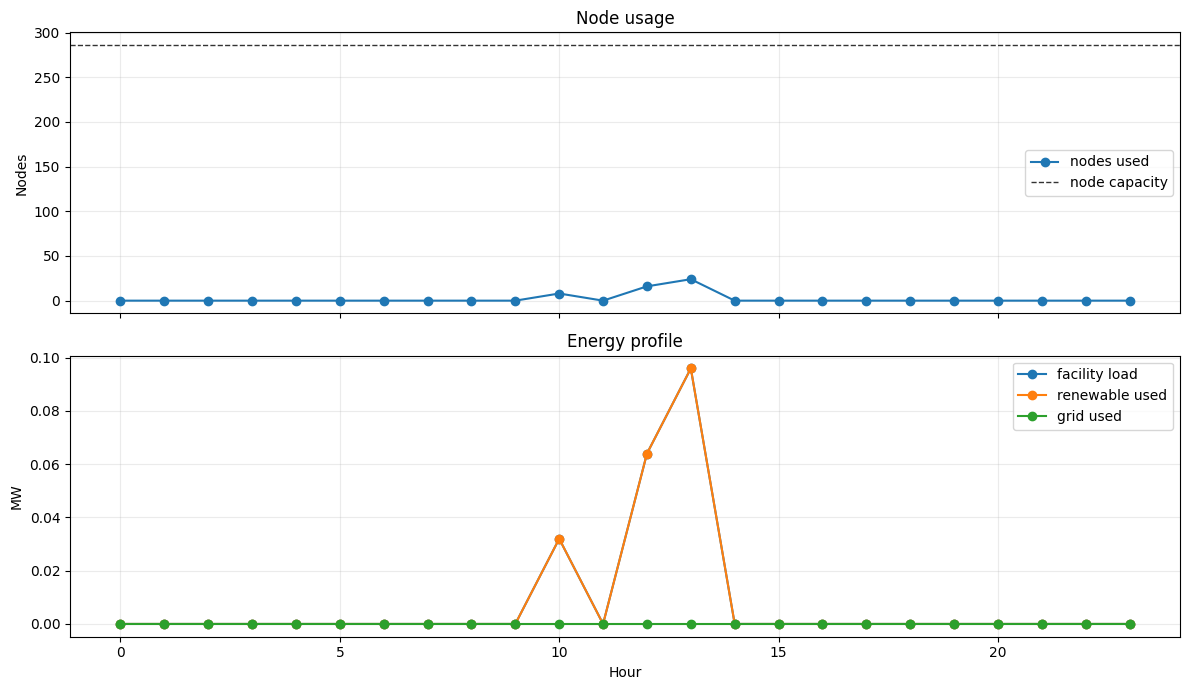

In [9]:
if not profile_df.empty:
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    axes[0].plot(profile_df["hour"], profile_df["node_used"], marker="o", label="nodes used")
    axes[0].axhline(float(clusters_df["gpu_capacity"].sum()), color="#333333", linestyle="--", linewidth=1, label="node capacity")
    axes[0].set_ylabel("Nodes")
    axes[0].set_title("Node usage")
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    axes[1].plot(profile_df["hour"], profile_df["facility_load_mw"], marker="o", label="facility load")
    axes[1].plot(profile_df["hour"], profile_df["renewable_used_mw"], marker="o", label="renewable used")
    axes[1].plot(profile_df["hour"], profile_df["grid_used_mw"], marker="o", label="grid used")
    axes[1].set_xlabel("Hour")
    axes[1].set_ylabel("MW")
    axes[1].set_title("Energy profile")
    axes[1].legend()
    axes[1].grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


## 7. QUBO in Block and Node Units

We now build two reduced QUBOs from the same tiny instance:

```text
QUBO block mode: gpu_count_required = block_units_required, capacity = block_capacity
QUBO node mode:  gpu_count_required = node_units_required,  capacity = node_capacity
```

The assignment variables are the same because windows and compatible clusters are the same. The difference is the GPU-capacity slack encoding:

- block mode has fewer slack bits and is more quantum-friendly;
- node mode is closer to the physical cluster but increases QUBO size.

Both QUBOs use the same energy inputs as Gurobi, but with a reduced objective: fixed-PUE energy cost plus GPU-capacity penalty plus an optional peak-smoothing proxy. Renewable/grid dispatch is not explicitly modeled in this QUBO.


In [10]:
def build_qubo_inputs(unit_mode: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Prepare jobs and clusters for one QUBO GPU unit mode."""

    jobs_unit, clusters_unit = adapt_gpu_unit(jobs_raw, clusters_raw, unit_mode)  # type: ignore[arg-type]
    jobs_unit["cpu_required"] = 0.0
    jobs_unit["memory_required_gb"] = 0.0
    return jobs_unit, clusters_unit


def solve_qubo_with_simulated_annealing(unit_mode: str, num_reads: int = 1000) -> dict:
    """Build and sample one QUBO, returning the first feasible decoded schedule."""

    jobs_unit, clusters_unit = build_qubo_inputs(unit_mode)
    config_qubo = ModelConfig(
        contracted_power=facility_capacity_mw,
        renewable_price=35.0,
        peak_price=1000.0,
        delta_t=1.0,
        pue=float(hourly_df["pue"].iloc[0]),
    )
    qubo = build_scheduling_qubo(
        jobs_unit,
        hourly_df,
        clusters_unit,
        config_qubo,
        QuboPenaltyWeights(assignment=1000.0, gpu_capacity=100.0, peak_smoothing=0.0),
    )
    bqm = to_dimod_bqm(qubo)
    sampleset = SimulatedAnnealingSampler().sample(bqm, num_reads=num_reads, seed=123)
    hours = [int(hour) for hour in hourly_df["hour"].tolist()]

    best_schedule = pd.DataFrame()
    best_report = {"feasible": False, "violations": ["no feasible sample found"]}
    best_energy = None
    for sample, energy in sampleset.data(["sample", "energy"]):
        schedule = decode_qubo_sample(qubo, sample)
        report = validate_decoded_schedule(schedule, jobs_unit, clusters_unit, hours)
        if report["feasible"]:
            best_schedule = schedule
            best_report = report
            best_energy = float(energy)
            break

    return {
        "unit_mode": unit_mode,
        "qubo": qubo,
        "jobs": jobs_unit,
        "clusters": clusters_unit,
        "schedule": best_schedule,
        "validation": best_report,
        "energy": best_energy,
        "sampleset": sampleset,
    }

qubo_block_result = solve_qubo_with_simulated_annealing("block")
qubo_node_result = solve_qubo_with_simulated_annealing("node")

qubo_summary = pd.DataFrame([
    {
        "solver": "QUBO_block",
        "feasible": qubo_block_result["validation"]["feasible"],
        "energy": qubo_block_result["energy"],
        "variables": qubo_block_result["qubo"].num_variables,
        "assignment_variables": qubo_block_result["qubo"].metadata["num_assignment_variables"],
        "slack_variables": qubo_block_result["qubo"].metadata["num_slack_variables"],
        "quadratic_terms": qubo_block_result["qubo"].metadata["num_quadratic_terms"],
    },
    {
        "solver": "QUBO_node",
        "feasible": qubo_node_result["validation"]["feasible"],
        "energy": qubo_node_result["energy"],
        "variables": qubo_node_result["qubo"].num_variables,
        "assignment_variables": qubo_node_result["qubo"].metadata["num_assignment_variables"],
        "slack_variables": qubo_node_result["qubo"].metadata["num_slack_variables"],
        "quadratic_terms": qubo_node_result["qubo"].metadata["num_quadratic_terms"],
    },
])
qubo_summary


,solver,feasible,energy,variables,assignment_variables,slack_variables,quadratic_terms
0,QUBO_block,True,6.72,65,25,40,287
1,QUBO_node,True,6.72,97,25,72,595


In [11]:
qubo_block_schedule = qubo_block_result["schedule"]
qubo_node_schedule = qubo_node_result["schedule"]

qubo_block_schedule, qubo_node_schedule


(               job_id     assigned_cluster  start_hour  duration   power  \
 0  seren_pretrain_005  seren_pretrain_pool          12         1  0.0256   
 1  seren_pretrain_002  seren_pretrain_pool          13         1  0.0256   
 2  seren_pretrain_000  seren_pretrain_pool          14         1  0.0256   
 3  seren_pretrain_004  seren_pretrain_pool          14         1  0.0256   
 4  seren_pretrain_003  seren_pretrain_pool          15         1  0.0256   
 5  seren_pretrain_001  seren_pretrain_pool          16         1  0.0256   
 
    gpu_count_required  cpu_required  memory_required_gb  qubo_variable  
 0                 1.0           0.0                 0.0             20  
 1                 1.0           0.0                 0.0             12  
 2                 1.0           0.0                 0.0              1  
 3                 1.0           0.0                 0.0             18  
 4                 1.0           0.0                 0.0             15  
 5             

## 8. Gurobi vs QUBO Comparison for Tiny

This comparison is intentionally narrow. It checks whether the three approaches produce feasible schedules on the same tiny job set.

Interpretation:

- `Gurobi_node` is the physical reference for this notebook.
- `QUBO_block` is the quantum-friendly reduced version.
- `QUBO_node` is mathematically closer to Gurobi's resource unit but has more slack variables.

Objective values are not directly comparable because Gurobi models renewable/grid dispatch explicitly, while QUBO uses a reduced Hamiltonian with penalties.


In [12]:
comparison_rows = []
comparison_rows.append({
    "solver": "Gurobi_node",
    "feasible": bool(model.SolCount),
    "objective_or_energy": model.ObjVal if model.SolCount else None,
    "assigned_jobs": len(schedule_df),
    "resource_unit": "node",
})
for label, result in [("QUBO_block", qubo_block_result), ("QUBO_node", qubo_node_result)]:
    comparison_rows.append({
        "solver": label,
        "feasible": result["validation"]["feasible"],
        "objective_or_energy": result["energy"],
        "assigned_jobs": len(result["schedule"]),
        "resource_unit": result["unit_mode"],
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df


,solver,feasible,objective_or_energy,assigned_jobs,resource_unit
0,Gurobi_node,True,6.72,6,node
1,QUBO_block,True,6.72,6,block
2,QUBO_node,True,6.72,6,node
